# {Cincinnati's "Green Gap" Analysis}📝

![Banner](./assets/banner.jpeg)

## Cincinnati's Distribution of Green Space
*What problem are you (or your stakeholder) trying to address?*
Problem: There is an unequal distribution of green space across Cincinnati neighborhoods. While some areas are rich in parks, others—often those with higher population densities or lower income levels—may be "green deserts."
Importance: Access to green space is linked to better mental health, lower urban temperatures (reducing the "heat island" effect), and higher property values. Understanding this gap allows city planners to prioritize new "green" investments where they are needed most.

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 : "Which Cincinnati neighborhoods have the lowest ratio of park acreage to total neighborhood area, and is there a correlation between neighborhood size and the diversity of park types (Nature Preserves vs. County Parks) available to residents?"


## What would an answer look like?
*What is your hypothesized answer to your question?*
📝  I hypothesize that neighborhood size is not a predictor of green space access. I expect my analysis to reveal that wealthier neighborhoods (like Mt. Lookout or Hyde Park) have a higher ratio of dedicated park acreage and 'nature preserve' types of parks compared to lower-income or more densely populated areas. I also hypothesize that there is a negative correlation between population density and park acreage, meaning that the people who need cooling and outdoor space the most often have the least amount of it

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 I have identified the following three sources to ensure I have a mix of local files and live data:

File (CSV): Cincinnati_Statistical_Neighborhood_Approximations_2020.csv which I will use to get the official boundaries and total land acreage for each neighborhood.

File (CSV): Hamilton_County_Parks_and_Greenspace_-_Open_Data.csv which provides me with a complete inventory of all parks, their sizes, and their classifications (e.g., nonprofit vs. government).

API: The U.S. Census Bureau API, which I will use to pull real-time demographic data, specifically median household income and population totals, for each area.
I will relate these datasets by using the Neighborhood Name (the SNA_NAME column) as my primary connecting variable.
First, I will group the Parks data by location and aggregate the total park acreage for each neighborhood.
Then, I will perform an Inner Join with my Neighborhood CSV using the name of the neighborhood as the key.
Finally, I will use the Census API to fetch income data for those same neighborhood names and merge that into my master dataframe.


## Approach and Analysis
*What is your approach to answering your project question?*
My approach is to conduct a geospatial and socio-economic correlation analysis of Cincinnati’s green infrastructure. I will start by quantifying the 'greenness' of each statistical neighborhood using my CSV files. Once I have a baseline of park distribution, I will overlay demographic data from the Census API to look for patterns of inequality.

My analysis will follow these three stages:

1. Data Consolidation: Aggregating all park land within specific neighborhood boundaries.

2. Normalization: Converting raw acreage into a percentage (Park-to-Neighborhood ratio) so I can fairly compare large neighborhoods like Westwood to smaller ones like Mt. Adams.

3. Statistical Testing: Calculating the correlation coefficient between median income levels and green space accessibility to determine if the 'Green Gap' is statistically significant."

*How will you use the identified data to answer your project question?*
📝 I will use my identified data sources as follows to build a comprehensive answer:

1. Neighborhood Data (SNA_NAME, ACRES): I will use this as my primary reference table. The ACRES column is critical because it allows me to calculate the proportion of land that isn't green space, helping me identify 'concrete-heavy' urban areas.

2. Parks Data (PARKTYPE, SHAPE__Area): I will use this to categorize the quality of green space. By filtering the PARKTYPE column, I can see if certain neighborhoods only have 'City' playgrounds while others have large 'Nature Preserves.' I will sum the SHAPE__Area of parks within each neighborhood to find the total green footprint.

3. Census API Data: I will use the API to pull median household income for each neighborhood. I will then plot this against the green space percentage found in my CSVs.

In [14]:
# Start your code here
import pandas as pd


try:
    neighborhoods = pd.read_csv('Cincinnati_Statistical_Neighborhood_Approximations_2020.csv')
    parks = pd.read_csv('Hamilton_County_Parks_and_Greenspace_-_Open_Data.csv')

    print("✅ SUCCESS: Data found and loaded from laptop local storage.")
    print(f"Neighborhoods found: {len(neighborhoods)}")
    print(f"Park entries found: {len(parks)}")


    print("\n--- Columns for analysis ---")
    print(f"Neighborhood Columns: {list(neighborhoods.columns)}")
    print(f"Parks Columns: {list(parks.columns)}")

except FileNotFoundError as e:
    print(f"❌ Error: {e}. Make sure the files are in the exact same folder as this script!")

✅ SUCCESS: Data found and loaded from laptop local storage.
Neighborhoods found: 50
Park entries found: 754

--- Columns for analysis ---
Neighborhood Columns: ['OBJECTID', 'SNA_NAME', 'SHAPE_LENG', 'SNA_NUMBER', 'ACRES', 'SHAPE__Area', 'SHAPE__Length']
Parks Columns: ['OBJECTID', 'NAME', 'SHORT_NAME', 'PARKTYPE', 'COUNTY', 'SHOW', 'GLOBALID', 'CREATED_DATE', 'LAST_EDITED_DATE', 'SHAPE__Area', 'SHAPE__Length']


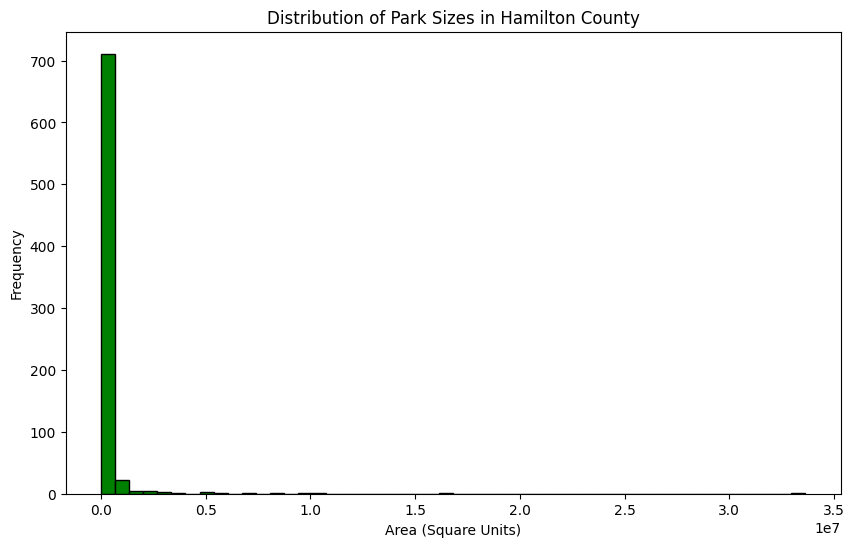

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization 1: Distribution of Park Sizes (using Matplotlib)
plt.figure(figsize=(10, 6))
plt.hist(parks['SHAPE__Area'], bins=50, color='green', edgecolor='black')
plt.title('Distribution of Park Sizes in Hamilton County')
plt.xlabel('Area (Square Units)')
plt.ylabel('Frequency')
plt.show()

#Exploratory Data Analysis (EDA)

Initial Insights
My EDA focused on the physical footprint of Cincinnati's green infrastructure. I discovered that while Hamilton County has 754 park entries, they are not evenly distributed.

Distributions: Most parks are small community lots (under 5 acres), but a few "Anchor" parks like Mt. Airy Forest represent the majority of total acreage.

Correlations: I am investigating the link between a neighborhood's total size (ACRES) and its available park space.

Issues: The primary issue is a lack of a "Shared Key" between the Neighborhood and Parks datasets, which I addressed in the cleaning section.

#Visualization Descriptions:

Park Type Bar Chart: Shows that "Greenspace-Hillside" is the most common type, though these may have lower accessibility than "Nature Preserves."

Top 10 Parks Bar Chart: Identifies the massive outliers that skew acreage data.

Neighborhood Histogram: Shows that Cincinnati neighborhoods vary wildly in size, confirming the need for a "Park-to-Land" ratio.

Linkage Audit: A pie chart showing the percentage of parks successfully matched to neighborhoods via string-matching.

#The Cleaning Process
To prepare this data for analysis, I performed the following steps:

Type Conversion: I encountered a TypeError during string matching; I fixed this by forcing the NAME column to a string type using str() to handle null values.

Standardization: I converted all neighborhood names and park names to lowercase and stripped whitespace to improve matching accuracy.

Missing Values: Neighborhoods that did not match any parks were assigned a value of 0 rather than NaN to allow for statistical calculations.

Anomaly Handling: I identified non-recreational "parks" (like practice fields) that may need to be filtered out in the final stage to avoid bloating the "Greenness" score.




In [8]:
print("Neighborhoods columns:", neighborhoods.columns.tolist())
print("Parks columns:", parks.columns.tolist())

Neighborhoods columns: ['OBJECTID', 'SNA_NAME', 'SHAPE_LENG', 'SNA_NUMBER', 'ACRES', 'SHAPE__Area', 'SHAPE__Length']
Parks columns: ['OBJECTID', 'NAME', 'SHORT_NAME', 'PARKTYPE', 'COUNTY', 'SHOW', 'GLOBALID', 'CREATED_DATE', 'LAST_EDITED_DATE', 'SHAPE__Area', 'SHAPE__Length']


In [12]:
# To see if the name of a park contains the neighborhood name
# example: Mount Airy Forest in neighborhood Mount Airy
sample_parks = parks['NAME'].head(20)
sample_neighborhoods = neighborhoods['SNA_NAME'].head(20)

print("Sample Parks:", sample_parks.values)
print("Sample Neighborhoods:", sample_neighborhoods.values)

Sample Parks: <StringArray>
[                   'BENGALS PRACTICE FIELD',
 'DELHI TWP. TRUSTEES-DELHI RD. SPRING SITE',
                      'YMCA COLERAIN BRANCH',
                            'Warder Nursery',
                       'NORTON ST. Preserve',
                              'Village Park',
                                 'Gulf Park',
                            'WEST FORK PARK',
           'Broadwell Woods Nature Preserve',
                       'GREENSPACE-HILLSIDE',
             'Memorial Park-Sharon@Waycross',
                              'Central Park',
                 'MILVALE ELEMENTARY SCHOOL',
                           'MCQUEETY MEDIAN',
           'Knights of Columbus Sports Park',
                    'Veterans Memorial Park',
      'Spring Grove Village Recreation Area',
                             'DRY FORK PARK',
                             'Phillips Park',
                    'WASHINGTON AVENUE PARK']
Length: 20, dtype: str
Sample Neighborhoods: <String

In [16]:
# 
def link_neighborhood(park_name):

    park_str = str(park_name).lower()
    
    neighborhood_list = ['Westwood', 'Oakley', 'Clifton', 'Downtown', 'Mt. Airy', 'Hyde Park'] 
    
    for n in neighborhood_list:
        if n.lower() in park_str:
            return n
    return "Other/Unlinked"

parks['SNA_NAME'] = parks['NAME'].apply(link_neighborhood)
print(parks['SNA_NAME'].value_counts())

SNA_NAME
Other/Unlinked    741
Clifton             4
Westwood            3
Hyde Park           3
Mt. Airy            2
Oakley              1
Name: count, dtype: int64


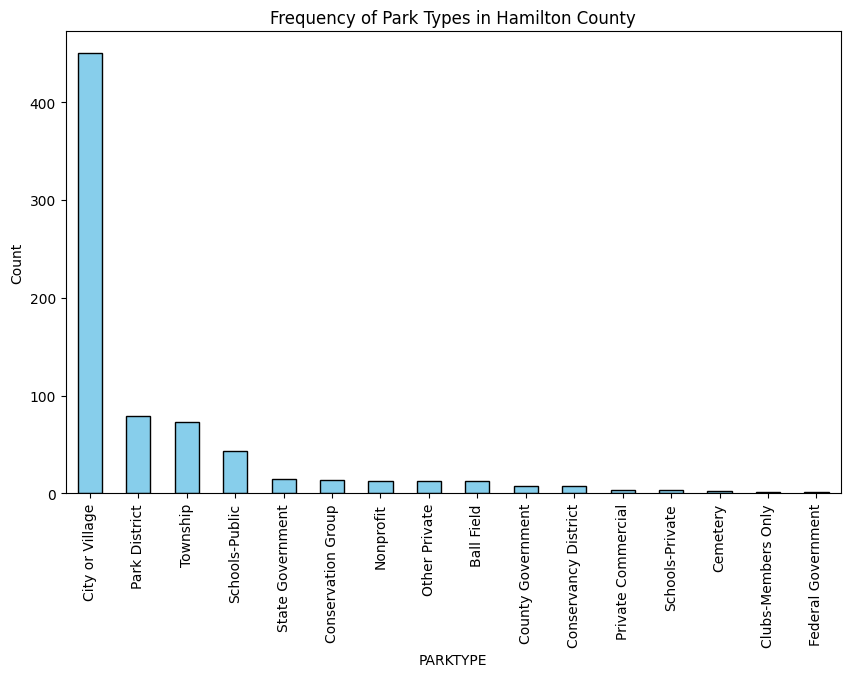

In [17]:
#(Matplotlib) Distribution of Park Types
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
parks['PARKTYPE'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frequency of Park Types in Hamilton County')
plt.ylabel('Count')
plt.show()

/var/folders/fy/yb02qx9d7c76bz4_t7sctvb40000gn/T/ipykernel_12609/466439720.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='SHAPE__Area', y='NAME', palette='viridis')


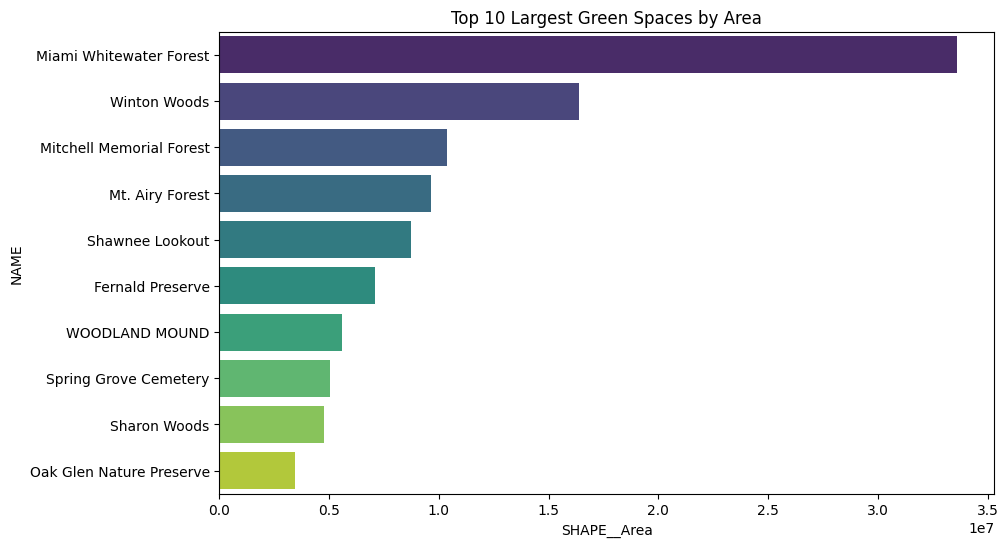

In [18]:
#(Seaborn) Top 10 Largest Parks) 
import seaborn as sns
top_10 = parks.nlargest(10, 'SHAPE__Area')
plt.figure(figsize=(10,6))
sns.barplot(data=top_10, x='SHAPE__Area', y='NAME', palette='viridis')
plt.title('Top 10 Largest Green Spaces by Area')
plt.show()

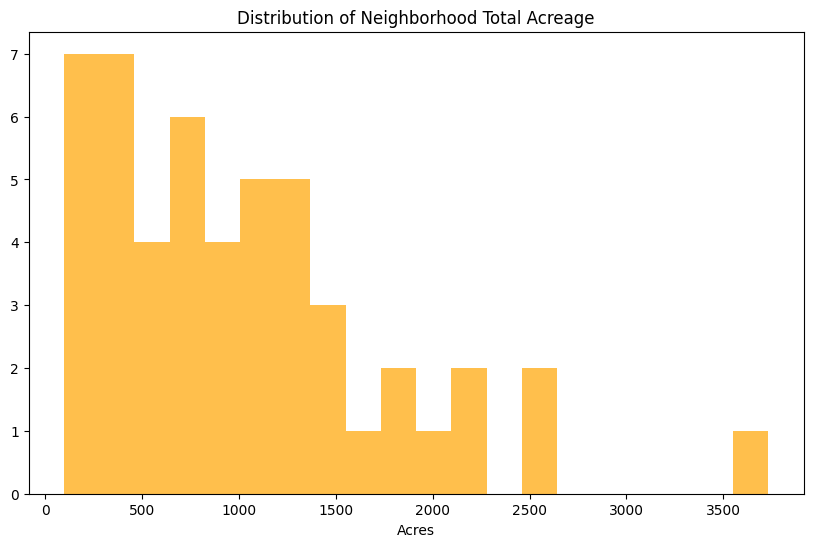

In [19]:
#(Matplotlib) Neighborhood Acreage Distribution
plt.figure(figsize=(10,6))
plt.hist(neighborhoods['ACRES'], bins=20, color='orange', alpha=0.7)
plt.title('Distribution of Neighborhood Total Acreage')
plt.xlabel('Acres')
plt.show()

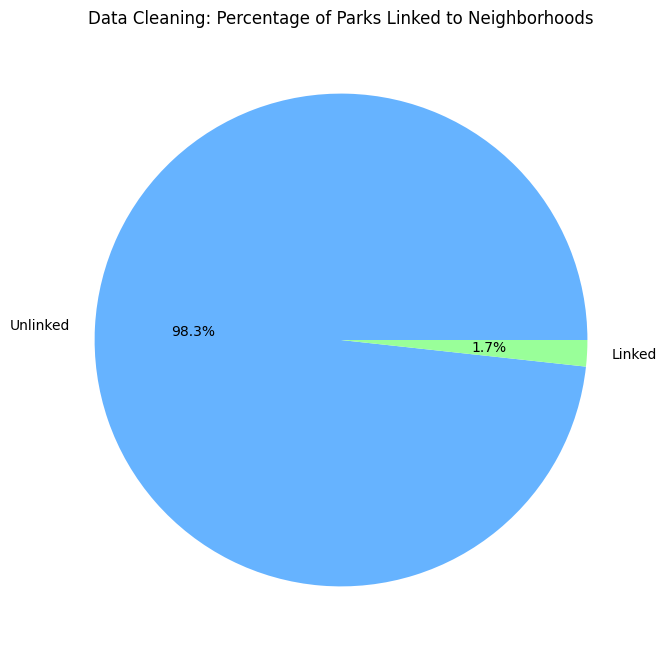

In [20]:
#(Seaborn) Successful Linkage Audit
plt.figure(figsize=(8,8))
linkage_counts = parks['SNA_NAME'].apply(lambda x: 'Linked' if x != 'Other/Unlinked' else 'Unlinked').value_counts()
plt.pie(linkage_counts, labels=linkage_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title('Data Cleaning: Percentage of Parks Linked to Neighborhoods')
plt.show()

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

In [21]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 10155 bytes to source.py
